# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [18]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [ ]:
from tensorflow.keras.utils import to_categorical

# Inspect the shapes of the datasets
display(X_train.shape, X_test.shape)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

display(y_train.shape, y_test.shape)

(60000, 28, 28)

(10000, 28, 28)

(60000, 10)

(10000, 10)

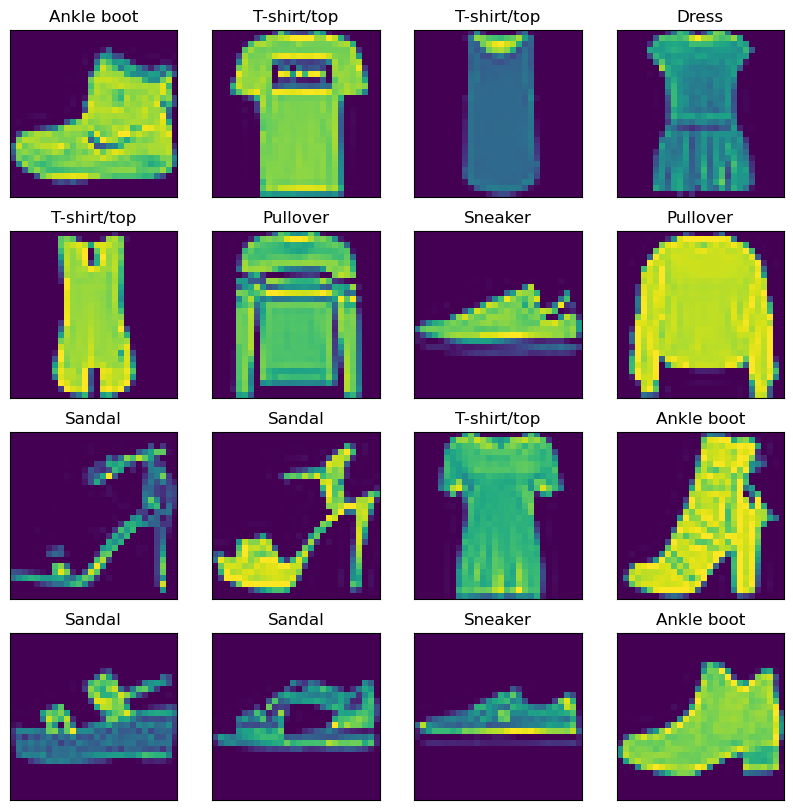

In [21]:
import matplotlib.pyplot as plt

# Verify the data looks as expected
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i].argmax()])
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**I expected better images quality, they look strange in color and resolution.**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model using `model.compile()`
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model with `model.fit()`
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate the model with `model.evaluate()`
model.evaluate(X_test, y_test)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7691 - loss: 0.6899 - val_accuracy: 0.8492 - val_loss: 0.4178
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8572 - loss: 0.4085 - val_accuracy: 0.8612 - val_loss: 0.3871
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8723 - loss: 0.3591 - val_accuracy: 0.8685 - val_loss: 0.3727
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8803 - loss: 0.3310 - val_accuracy: 0.8793 - val_loss: 0.3331
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8874 - loss: 0.3085 - val_accuracy: 0.8787 - val_loss: 0.3280
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8932 - loss: 0.2882 - val_accuracy: 0.8728 - val_loss: 0.3477
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8998 - loss: 0.2788 - val_accuracy: 0.8787 - val_loss: 0.3325
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9006 - loss: 0.2674 - val_accuracy: 0.

[0.34193694591522217, 0.8823000192642212]

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**The performance is not great. I expected a better accurracy, but it's not bad though. I think the performance is at this level cause the lack of more layers and dropout**

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [26]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate the model
model.evaluate(X_test, y_test)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.8120 - loss: 0.5396 - val_accuracy: 0.8857 - val_loss: 0.3168
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9016 - loss: 0.2679 - val_accuracy: 0.8987 - val_loss: 0.2767
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9237 - loss: 0.2057 - val_accuracy: 0.9022 - val_loss: 0.2661
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9422 - loss: 0.1576 - val_accuracy: 0.9043 - val_loss: 0.2794
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.9533 - loss: 0.1286 - val_accuracy: 0.9055 - val_loss: 0.2837
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.9634 - loss: 0.1020 - val_accuracy: 0.9087 - val_loss: 0.3025
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9720 - loss: 0.0787 - val_accuracy: 0.9068 - val_loss: 0.3225
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9774 - loss: 0.0626 - 

[0.4383189082145691, 0.9014999866485596]

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Yes, it did perform a little bit better than the baseline model by 1% more accuracy. Maily because the Conv2D layer learns about image features like edges, corners, contrast, etc.**

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [28]:
# A. Test Hyperparameters
Conv2D_filters = [32, 64, 128]  # Number of filters in the Conv2D layer
results = {} # Dictionary to store results

# For loop changing number of filters in Conv2D layer
for filters in Conv2D_filters:
    model = Sequential()

    model.add(Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

    # Store results for each configuration
    results[filters] = model.evaluate(X_test, y_test)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.8160 - loss: 0.5255 - val_accuracy: 0.8913 - val_loss: 0.2983
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9065 - loss: 0.2570 - val_accuracy: 0.8992 - val_loss: 0.2741
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9265 - loss: 0.2042 - val_accuracy: 0.9063 - val_loss: 0.2651
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9423 - loss: 0.1589 - val_accuracy: 0.9080 - val_loss: 0.2652
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9548 - loss: 0.1237 - val_accuracy: 0.9053 - val_loss: 0.2869
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9647 - loss: 0.1009 - val_accuracy: 0.9047 - val_loss: 0.3070
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9722 - loss: 0.0781 - val_accuracy: 0.9065 - val_loss: 0.3108
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9785 - loss: 0.0628 - 

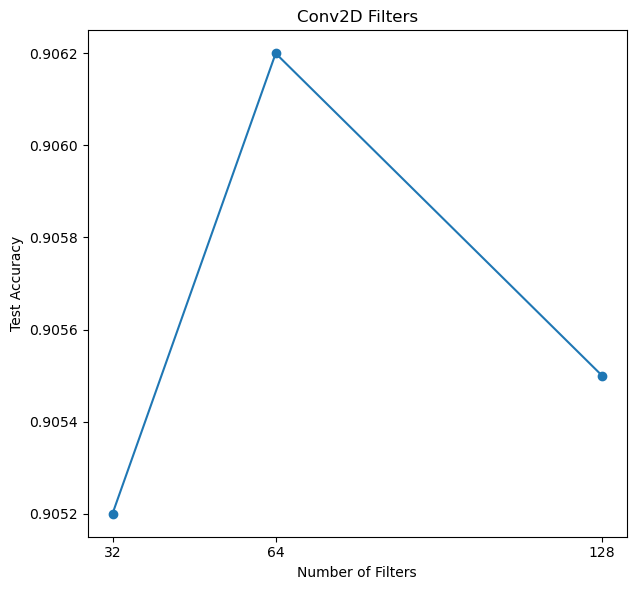

In [29]:
# Results for Conv2D filters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Conv2D Filters")
plt.xlabel("Number of Filters")
plt.ylabel("Test Accuracy")
plt.xticks(list(results.keys()))
plt.plot(list(results.keys()), [r[1] for r in results.values()], marker='o')

plt.tight_layout()
plt.show()

In [30]:
# B. Test presence or absence of regularization
from keras.layers import Dropout

dropout_rates = [0.0, 0.2]  # Different dropout rates to test
results_dropout = {} # Dictionary to store results

for rate in dropout_rates:
    model = Sequential()

    model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(rate))  # Add Dropout layer with the specified rate
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

    # Store results for each configuration
    results_dropout[rate] = model.evaluate(X_test, y_test)

Epoch 1/10


c:\Users\jairo\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.8118 - loss: 0.5431 - val_accuracy: 0.8858 - val_loss: 0.3189
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9070 - loss: 0.2553 - val_accuracy: 0.9063 - val_loss: 0.2747
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9274 - loss: 0.1979 - val_accuracy: 0.9090 - val_loss: 0.2632
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9427 - loss: 0.1573 - val_accuracy: 0.9050 - val_loss: 0.2825
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9552 - loss: 0.1211 - val_accuracy: 0.9072 - val_loss: 0.2702
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9671 - loss: 0.0942 - val_accuracy: 0.9045 - val_loss: 0.3242
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.9735 - loss: 0.0746 - val_accuracy: 0.9082 - val_loss: 0.3379
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9800 - loss: 0.0592 - val_accurac

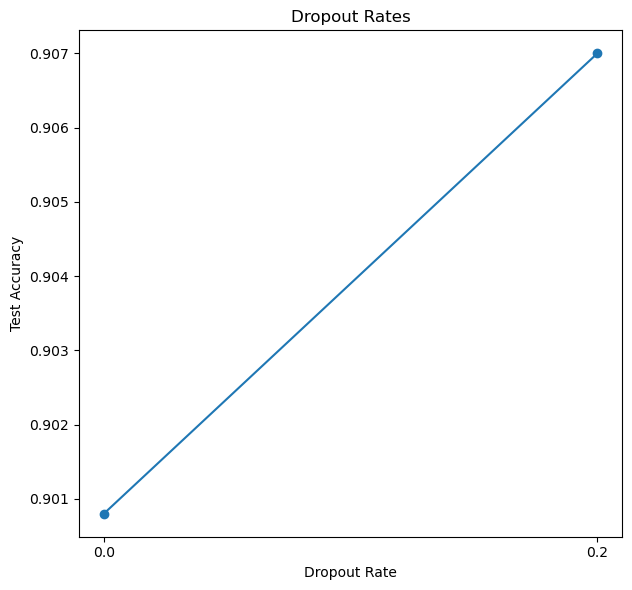

In [31]:
# Results for Dropout rates
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.title("Dropout Rates")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.xticks(list(results_dropout.keys()))
plt.plot(list(results_dropout.keys()), [r[1] for r in results_dropout.values()], marker='o')

plt.tight_layout()
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Yes, I got improvement in performance. Among the hyperparameter to experiment with, I picked the number of filters for the Conv2D layer. Having the 64 filters giving better results than the 32 or 128**  
**As for the regularization technique, I used the dropout (0.0 = no dropout, 0.2 = using dropout) getting a better accuracy using this technique**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [32]:
model = Sequential()

model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

model.evaluate(X_test, y_test)

Epoch 1/10


c:\Users\jairo\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.8007 - loss: 0.5688 - val_accuracy: 0.8880 - val_loss: 0.3072
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.8967 - loss: 0.2791 - val_accuracy: 0.8952 - val_loss: 0.2868
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9145 - loss: 0.2337 - val_accuracy: 0.9047 - val_loss: 0.2692
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9262 - loss: 0.1958 - val_accuracy: 0.9085 - val_loss: 0.2650
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9377 - loss: 0.1700 - val_accuracy: 0.9053 - val_loss: 0.2823
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.9482 - loss: 0.1389 - val_accuracy: 0.9120 - val_loss: 0.2816
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9555 - loss: 0.1175 - val_accuracy: 0.9117 - val_loss: 0.2881
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9618 - loss: 0.1034 - val_accurac

[0.3540636897087097, 0.9049000144004822]

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**The final model performed better than the baseline, I think it must do with the use of hyperparameters and regularization techniques. But I think adding pooling could improve the current results**

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.